# Python for Data Science
## Session 6
### Datasets – Pandas I 

---

## Outline

1. Pandas

2. Loading and exploring datasets 

3. Data cleaning and preprocessing with Pandas 

---

## Pandas I

**Pandas** is one of the most used libraries within the Data Science community. It provides a full set of tools to work with:
- 2D data via DataFrame class
    - SQL/Spreadsheet-like datasets (tabular data)
    - Arbitrary matrix data with row and column labels
    - Any type of dataset with observational / statistical data (no labels needed)
- 1D data via Series class
    - Time series data


## Pandas I

As one can see, from the type of datasets **Pandas** can handle, most of the use cases found in Data Science are covered, e.g. finance, health, biology, supply chain, or meteorology. Things **Pandas** do:

1. Handling missing data
2. Change DataFrame size, adding and removing columns and rows at will
3. Automatic data alignment of misaligned data
4. Group by operation
5. Data conversion
6. Advanced indexing
7. Data Merging and joining 
8. Reshaping data
9. Hierarchical indexing
10. Read/write support for CSV, Excel, databases, and fast HDF5 format.
11. Time series manipulation, frequency convertion, window moving statistics


## Pandas I

Let's create a few dataframes using different data structures and see how to start navigating them


In [ ]:
## Let's create a simple DataFrame to work with
import pandas as pd
dataset = [
    {
        "name": "Amelie",
        "age": 35
    },
    {
        "name": "Edgar",
        "age": 32
    }
]
df = pd.DataFrame(dataset)
df

In [ ]:
# Using a slightly different data struture
data = {'Name': ['Amelie', 'Edgar', 'Carlos', 'Victor'],
        'Age': [24, 27, 22, 32],
        'Country': ['FR', 'FR', 'ES', 'GE']}
df = pd.DataFrame(data)
df

In [ ]:
# we can quickly visualize all the columns a dataframe contains by simply
df.columns

In [ ]:
# Another important thing we can do is to set up any specific index
# these act as row labels
df = pd.DataFrame(data, index=['A', 'B', 'C', 'D'])
df

In [ ]:
# Similar to lists and arrays, we can slice
df[:2]

In [ ]:
# Similar to lists and arrays, we can also access elements making use of loc and iloc
df.loc['B':'D']

In [ ]:
# We can access elements using loc and iloc
df.iloc[1:]

In [ ]:
# We can also access element attributes by using at
df.at[0, 'Age']

In [ ]:
# if we wanted to do it with iloc, we would need to pass positions
df.iloc[0,1]

In [ ]:
# Important: to modify a specific value we can use at, loc and iloc
df.loc['B', 'Age'] = 123
df

In [ ]:
# we can also check what elements satisfy some criteria by column (attribute)
df['Age'] > 25

In [ ]:
# and show them
df[df['Age'] > 25]

In [ ]:
# or modify a simple attribute of those that satisfy certain condition
df.loc[df['Age'] > 25, 'Name'] = 'Unknown' # df.iloc[df['Age'] > 25, 0] = 'Unknown'
df

In [ ]:
# we can also, similar to the way we do with dicts, add new columns
df['Residency'] = [True, False, True, False]

In [ ]:
# or add new elements
df.loc[6] = ['Jordi', 23, 'ES', False]
df.loc[9] = ['Anna', 19, 'ES', False]
df

In [ ]:
# There are other methods one can also call
df.head(2)

In [ ]:
# There are other methods one can also call
df.tail(2)

In [ ]:
df.shape # to get the dataframe shape

In [ ]:
df.dtypes

In [ ]:
df['Age'].astype('float')

In [ ]:
# Same as numpy, we can find the unique method
df['Country'].unique()

## Pandas I

Among the different methods two important ones are **info** and **describe**:

In [ ]:
df.info()

In [ ]:
df.describe()

## Pandas I

And how do we know about missing elements and handle them?

In [ ]:
# What about missing values? Missing values are usually represented as NaN (Not a Number)
import numpy as np
data = {'Name': ['Amelie', 'Edgar', 'Carlos', 'Victor'],
        'Age': [24, 27, 22, 32],
        'Country': ['FR', np.nan, 'ES', 'GE']}
df = pd.DataFrame(data)
df

In [ ]:
# we can simply know which ones present missing values by using isna or isnull
df.isna() # at the whole dataframe level

In [ ]:
# and at the column level
df['Country'].isnull() # same as .isna()

In [ ]:
# Simple way of filling these ones is achieved by calling fillna
df.fillna('RE')

In [ ]:
# There's also possible thing you can do, use the mode (most common value)
#df['Country'].mode()
df.fillna(df['Country'].mode()[0])

In [ ]:
# IMPORTANT: if we check again the dataframe, we will see that the dataframe keeps having NaNs
# This is because the intented behaviour is usually to keep the DataFrame immutable
# If you want to actually modify you can pass ot fillna, inplace=True
df

In [ ]:
# A more drastic operation is to drop any column or row with missing values using
# here, we will modify the original dataframe and drop the rows and cols with nans
df.at[0, 'Age'] = np.nan
df

In [ ]:
df.dropna()

## Pandas I

One of the handy tools you have in **Pandas** is **groupby**. It allows you to group by any unique attributes within a column and get statistics:
- count
- mean
- sum
- min and max
- multiple aggregations
- group using multiple columns

In [ ]:
data = {
    'Name': ['Amelie', 'Edgar', 'Carlos', 'Victor', 'Sofia', 'Jin', 
             'Marta', 'Ali', 'Emily', 'Ravi', 'Chen', 'Fatima', 'Saham'],
    'Age': [24, 27, 22, 32, 29, 31, 28, 26, 23, 34, 25, 30, 26],
    'Country': ['FR', 'US', 'ES', 'GE', 'PT', 'KR',
                'ES', 'AE', 'US', 'IN', 'CN', 'AE', 'AE'],
    'Salary': [70000, 110000, 65000, 82000, 48000, 39000, 45000,
            90000, 97000, 31000, 49000, 85000, 80000]   
}

df = pd.DataFrame(data)
df

In [ ]:
# let's count how many we have per country
df.groupby('Country').count()

In [ ]:
df.groupby('Country')['Age'].mean() # now let's know the average age per country

In [ ]:
df.groupby('Country')['Salary'].sum() # total sum of their salaries

In [ ]:
# Multiple Aggregations
df.groupby('Country').agg({'Salary': ['min', 'max'], 'Age': 'mean'})

In [ ]:
# grouping using more than one column
df.groupby(['Country', 'Age'])['Salary'].count()

## Pandas I

Let's load *Netflix* titles and do some exercices

In [ ]:
path = '/Users/BennyHeist/Desktop/Esade/Python/Workbooks/netflix_titles.csv'

df = pd.read_csv(path)
df

In [ ]:
df.columns

## Pandas I
Let's do the following exercices:

1. Count Missing Values in Each Column

2. Fill Missing 'country' Values with "Unknown"

3. Filter for TV Shows Only

4. Count the Number of Entries per Rating

5. Add a Column Showing Content Age (how many years since it came out)


In [ ]:
df.info()

In [ ]:
#count missing values
df.isna().sum()

In [ ]:
#fill the missing country values with 'Unknown'
df['country'].fillna('Unknown', inplace=True)
df.info()

In [ ]:
df[df['type']=='TV Show']

In [ ]:
print(df.groupby('rating').count())

print(df.groupby('rating')['title'].count())


In [ ]:
from datetime import datetime

df['date_added'] = pd.to_datetime(df['date_added'], format="%B %d, %Y", errors='coerce')

df['Content_Age'] = datetime.now() - df['date_added']

print(df['Content_Age'])


## Pandas I

Let's now load the *Titanic* dataset and practice a little bit more:

1. Count the Missing Values in Each Column

2. Fill Missing 'Age' Values with the Mean Age

3. Fill Missing 'Embarked' Values with the Mode (Most Common Value)

4. Filter and Display Passengers Who Paid a Fare Above the Average Fare

5. Add a New Column Indicating Family Size. Create a new column 'FamilySize' as the sum of 'SibSp' (siblings/spouses) and 'Parch' (parents/children)

## Pandas I

Home exercises for Netflix:

1. Is there any missing rating?
2. How many films in 2021 correspond to your country?
3. What's the number of movies in 2020 with full information?
4. Give me the year with more titles,
5. and what has been the average in terms of releases from 2010. 

And for Titanic:

1. Calculate Gender-Based Survival Percentage

2. Calculate Survival Percentage Grouped by Gender and Class

In [1]:
import pandas as pd

path = '/Users/BennyHeist/Desktop/Esade/Python/Workbooks/netflix_titles.csv'

df = pd.read_csv(path)


df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


1. Is there any missing rating?

In [2]:
# Check for missing values in all columns

print(df.isna().sum())

# Check specifically for missing values in the 'rating' column
if df['rating'].isna().sum() != 0 : 
    print ('There are', df['rating'].isna().sum(),'ratings missing')

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64
There are 4 ratings missing


2. How many films in 2021 correspond to your country?

In [3]:
# convert 'date_added' to datetime format
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Filter rows where 'date_added' is from 2021
df_2021 = df[df['date_added'].dt.year == 2021]

# Further filter for rows where 'country' is Germany (excluding 'West Germany')
df_2021_germany = df_2021[df_2021['country'].str.strip() == 'Germany']

# Filter for movies only
df_2021_germany_films = df_2021_germany[df_2021_germany['type'] == 'Movie']

# Output the count of movies
print(f"There are {df_2021_germany_films['title'].count()} films from 2021 corresponding to Germany (excluding 'West Germany').")


There are 5 films from 2021 corresponding to Germany (excluding 'West Germany').


3. What's the number of movies in 2020 with full information?

In [4]:
# convert 'date_added' to datetime format
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Filter the DataFrame for rows where the year in 'date_added' is 2020
df_2020 = df[df['date_added'].dt.year == 2020]

# Filter rows with no missing values (full information)
df_2020_full = df_2020[df_2020.notna().all(axis=1)]

# Further filter for movies only
df_2020_full_films = df_2020_full[df_2020_full['type'] == 'Movie']



#print(f"There are {full_info_count} movies from 2020 with full information.")
print(f"There are {df_2020_full_films['title'].count()} films from 2020 with full information")


There are 1151 films from 2020 with full information


4. Give me the year with more titles.


In [5]:
# Group the data by release year and count the number of titles per year
titles_per_year = df['release_year'].value_counts()

# Find the year with the maximum number of titles
most_titles_year = titles_per_year.idxmax()
most_titles_count = titles_per_year.max()

print(f"The year with the most titles is {most_titles_year}, with {most_titles_count} titles.")


The year with the most titles is 2018, with 1147 titles.


5. and what has been the average in terms of releases from 2010. 


In [6]:
# Filter the DataFrame for release years from 2010 onwards
df_from_2010 = df[df['release_year'] >= 2010]

# Group by release year and count the number of titles per year
titles_per_year = df_from_2010['release_year'].value_counts()

# Calculate the average number of releases per year
average_releases = titles_per_year.mean()

print(f"The average number of releases per year from 2010 onwards is {average_releases:.2f}.")


The average number of releases per year from 2010 onwards is 622.67.


And for Titanic:

In [7]:
import pandas as pd

path = '/Users/BennyHeist/Desktop/Esade/Python/Workbooks/train_and_test2.csv'

df = pd.read_csv(path)

#print(df)


print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 28 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Passengerid  1309 non-null   int64  
 1   Age          1309 non-null   float64
 2   Fare         1309 non-null   float64
 3   Sex          1309 non-null   int64  
 4   sibsp        1309 non-null   int64  
 5   zero         1309 non-null   int64  
 6   zero.1       1309 non-null   int64  
 7   zero.2       1309 non-null   int64  
 8   zero.3       1309 non-null   int64  
 9   zero.4       1309 non-null   int64  
 10  zero.5       1309 non-null   int64  
 11  zero.6       1309 non-null   int64  
 12  Parch        1309 non-null   int64  
 13  zero.7       1309 non-null   int64  
 14  zero.8       1309 non-null   int64  
 15  zero.9       1309 non-null   int64  
 16  zero.10      1309 non-null   int64  
 17  zero.11      1309 non-null   int64  
 18  zero.12      1309 non-null   int64  
 19  zero.1

1. Calculate Gender-Based Survival Percentage

In [8]:
# convert numbers to strings within the sex-column if binary values are existing
df['Sex'] = df['Sex'].replace({0: 'male', 1: 'female'})


# Group by gender and calculate survival percentages
gender_survival = df.groupby('Sex')['2urvived'].mean() * 100

# Print the result with gender labels 
for gender, survival_rate in gender_survival.items():
    print(f"The survival percentage for {gender} is {survival_rate:.2f}%.")


The survival percentage for female is 50.00%.
The survival percentage for male is 12.93%.


In [9]:
# Group by both Gender and Class, then calculate survival percentage
gender_class_survival = df.groupby(['Sex', 'Pclass'])['2urvived'].mean() * 100

# Print the survival percentages
print("Survival percentages grouped by gender and class:")
for (gender, pclass), survival_rate in gender_class_survival.items():
    print(f"Gender: {gender} & Class: {pclass} -> Survival Rate: {survival_rate:.2f}%")


Survival percentages grouped by gender and class:
Gender: female & Class: 1 -> Survival Rate: 63.19%
Gender: female & Class: 2 -> Survival Rate: 66.04%
Gender: female & Class: 3 -> Survival Rate: 33.33%
Gender: male & Class: 1 -> Survival Rate: 25.14%
Gender: male & Class: 2 -> Survival Rate: 9.94%
Gender: male & Class: 3 -> Survival Rate: 9.53%


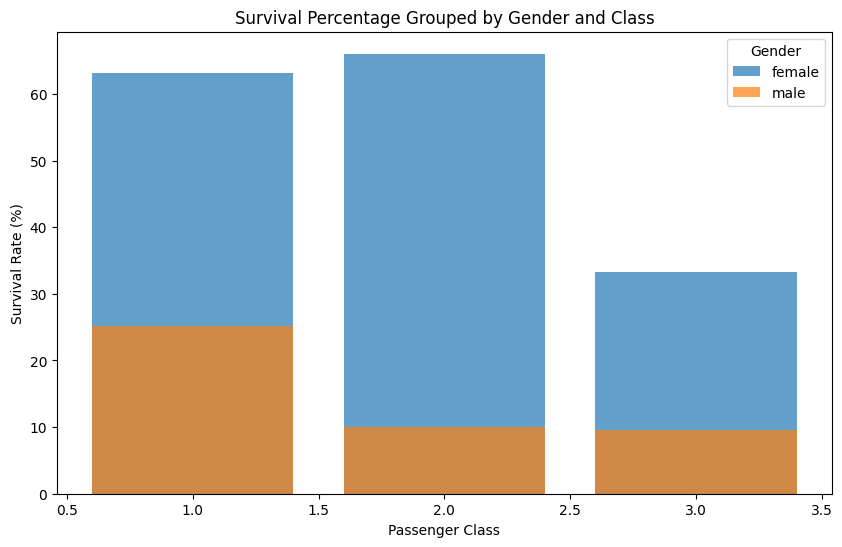

In [10]:
#after our last class about visualization, I thought it would be nice to implement a simple visualization here as well ;) 

import matplotlib.pyplot as plt

# Convert results to a DataFrame for easy plotting
gender_class_survival_df = gender_class_survival.reset_index()
gender_class_survival_df.columns = ['Gender', 'Class', 'Survival Rate']

# Create a bar chart
plt.figure(figsize=(10, 6))
for gender in gender_class_survival_df['Gender'].unique():
    subset = gender_class_survival_df[gender_class_survival_df['Gender'] == gender]
    plt.bar(subset['Class'], subset['Survival Rate'], label=gender, alpha=0.7)

# Add labels and title
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate (%)')
plt.title('Survival Percentage Grouped by Gender and Class')
plt.legend(title='Gender')
plt.show()
